# ch316 — CNN Architectures

## 1. From AlexNet to EfficientNet

The history of CNNs is a series of insights about how to use depth, width, and
residual connections more effectively.

| Architecture | Year | Key idea |
|---|---|---|
| AlexNet | 2012 | Deep CNN on GPU; ReLU; dropout |
| VGGNet | 2014 | Only 3×3 convs; increasing depth |
| GoogLeNet | 2014 | Inception module: multiple kernel sizes in parallel |
| ResNet | 2015 | Residual connections: skip over layers |
| DenseNet | 2017 | Dense connections: each layer receives all prior outputs |
| EfficientNet | 2019 | Compound scaling: depth × width × resolution |

*(Residual connections relate to Taylor series remainder *(ch220)* and ODE solvers *(ch226)*.)*

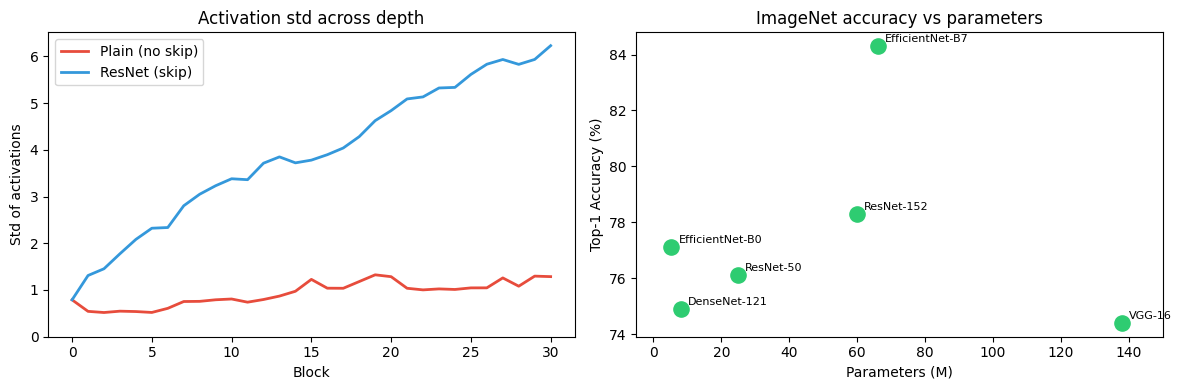

In [1]:
import numpy as np
import matplotlib.pyplot as plt


def relu(z): return np.maximum(0, z)
def conv_shape(H: int, k: int, s: int, p: int) -> int:
    return (H + 2*p - k) // s + 1

# ── ResNet-style Residual Block (pure NumPy) ──
class ResidualBlock:
    """
    Pre-activation ResNet block:
    x → BN → ReLU → Conv3x3 → BN → ReLU → Conv3x3 → + x
    Implemented with dense weight matrices for a 1D analogue.
    """

    def __init__(self, dim: int, seed: int = 0):
        rng = np.random.default_rng(seed)
        s = np.sqrt(2.0 / dim)
        self.W1 = rng.normal(0, s, (dim, dim))
        self.b1 = np.zeros(dim)
        self.W2 = rng.normal(0, s, (dim, dim))
        self.b2 = np.zeros(dim)
        self.gamma1 = np.ones(dim); self.beta1 = np.zeros(dim)
        self.gamma2 = np.ones(dim); self.beta2 = np.zeros(dim)

    def _layer_norm(self, x, gamma, beta, eps=1e-6):
        mean = x.mean(-1, keepdims=True); var = x.var(-1, keepdims=True)
        return gamma * (x - mean) / np.sqrt(var + eps) + beta

    def forward(self, x: np.ndarray) -> np.ndarray:
        identity = x
        out = relu(self._layer_norm(x, self.gamma1, self.beta1))
        out = out @ self.W1.T + self.b1
        out = relu(self._layer_norm(out, self.gamma2, self.beta2))
        out = out @ self.W2.T + self.b2
        return out + identity  # ← residual connection

# Show gradient flow: without vs with residual connections
rng = np.random.default_rng(42)
d = 64; n_blocks = 30

def forward_no_residual(x, blocks):
    for b in blocks: x = relu(x @ b.W1.T + b.b1); return x

def forward_residual(x, blocks):
    for b in blocks: x = b.forward(x); return x

blocks = [ResidualBlock(d, seed=i) for i in range(n_blocks)]
x0 = rng.normal(0, 1, (1, d))

# Measure std of activation at each depth
stds_plain = [x0.std()]
stds_res   = [x0.std()]

xp = x0.copy(); xr = x0.copy()
for b in blocks:
    xp = relu(xp @ b.W1.T + b.b1); stds_plain.append(xp.std())
    xr = b.forward(xr);             stds_res.append(xr.std())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(stds_plain, color='#e74c3c', lw=2, label='Plain (no skip)')
ax1.plot(stds_res,   color='#3498db', lw=2, label='ResNet (skip)')
ax1.set_title('Activation std across depth')
ax1.set_xlabel('Block'); ax1.set_ylabel('Std of activations')
ax1.legend(); ax1.set_ylim(bottom=0)

# Architecture diagram text summary
architectures = {
    'VGG-16': {'params_M': 138, 'layers': 16, 'top1_acc': 74.4},
    'ResNet-50': {'params_M': 25,  'layers': 50, 'top1_acc': 76.1},
    'ResNet-152': {'params_M': 60, 'layers': 152, 'top1_acc': 78.3},
    'DenseNet-121': {'params_M': 8, 'layers': 121, 'top1_acc': 74.9},
    'EfficientNet-B0': {'params_M': 5.3, 'layers': 237, 'top1_acc': 77.1},
    'EfficientNet-B7': {'params_M': 66, 'layers': 813, 'top1_acc': 84.3},
}
names = list(architectures.keys())
params = [architectures[n]['params_M'] for n in names]
accs   = [architectures[n]['top1_acc'] for n in names]
ax2.scatter(params, accs, s=120, color='#2ecc71', zorder=5)
for name, x, y in zip(names, params, accs):
    ax2.annotate(name, (x, y), xytext=(5, 3), textcoords='offset points', fontsize=8)
ax2.set_title('ImageNet accuracy vs parameters')
ax2.set_xlabel('Parameters (M)'); ax2.set_ylabel('Top-1 Accuracy (%)')
ax2.set_xlim(-5, 150)

plt.tight_layout()
plt.savefig('ch316_cnn_architectures.png', dpi=120)
plt.show()

## 2. The residual connection insight

Without skip connections, gradients in deep networks vanish or explode
*(discussed in ch306)*. A residual block computes:

$$y = F(x) + x$$

During backpropagation:

$$\frac{\partial y}{\partial x} = \frac{\partial F(x)}{\partial x} + I$$

The identity term $I$ ensures gradients always have a direct path back to early layers,
regardless of the nonlinear function $F(x)$. ResNet trains 1000+ layer networks stably.

## 3. Summary

- VGG: simple 3×3 convs stacked; shows depth matters more than filter size.
- ResNet: residual connections solve vanishing gradients; enables depth of 50–1000 layers.
- DenseNet: dense connections; feature reuse; fewer parameters.
- EfficientNet: compound scaling of depth, width, resolution simultaneously.

## 4. Forward and backward references

**Used here:** conv layers *(ch314)*, pooling *(ch315)*, batch norm *(ch310)*,
vanishing gradients *(ch306)*.

**This will reappear in ch335 — Project: CNN Image Classification**, where a ResNet-style
block is incorporated into the project network.